In [268]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

 # 1. Data Loading

In [269]:
# Load data
df = pd.read_csv('./diabetes.csv')

# Display basic information with clear separators
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\n" + "-" * 50)
print("DESCRIPTIVE STATISTICS")
print("-" * 50)
print(df.describe().T.round(2))  # Rounded for readability

print("\n" + "-" * 50)
print("FIRST 5 ROWS")
print("-" * 50)
print(df.head())

print("\n" + "-" * 50)
print("DATA INFO")
print("-" * 50)
print(df.info())

DATASET OVERVIEW

Dataset Shape: 768 rows × 9 columns

--------------------------------------------------
DESCRIPTIVE STATISTICS
--------------------------------------------------
                          count    mean     std    min    25%     50%     75%  \
Pregnancies               768.0    3.85    3.37   0.00   1.00    3.00    6.00   
Glucose                   768.0  120.89   31.97   0.00  99.00  117.00  140.25   
BloodPressure             768.0   69.11   19.36   0.00  62.00   72.00   80.00   
SkinThickness             768.0   20.54   15.95   0.00   0.00   23.00   32.00   
Insulin                   768.0   79.80  115.24   0.00   0.00   30.50  127.25   
BMI                       768.0   31.99    7.88   0.00  27.30   32.00   36.60   
DiabetesPedigreeFunction  768.0    0.47    0.33   0.08   0.24    0.37    0.63   
Age                       768.0   33.24   11.76  21.00  24.00   29.00   41.00   
Outcome                   768.0    0.35    0.48   0.00   0.00    0.00    1.00   

         

# 2. Data Preprocessing

## Step 1: Handle missing/zero values (medically impossible zeros)

In [270]:
print(f"Missing values: {df.isnull().sum().sum()}")

# Check zeros in medical features
medical_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in medical_features:
    zero_count = (df[col] == 0).sum()
    print(f"  {col}: {zero_count} zeros")

# Replace zeros with NaN for imputation
df_processed = df.copy()
for col in medical_features:
    df_processed.loc[df_processed[col] == 0, col] = np.nan
print("Zeros converted to NaN for proper imputation in the preprocessing pipeline.")


Missing values: 0
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros
Zeros converted to NaN for proper imputation in the preprocessing pipeline.


## Step 2: Handle Outliers

In [271]:
# handle outliers function
def handle_outliers(data, column):
    non_nan_data = data[column].dropna()

    if len(non_nan_data) == 0:
        return

    Q1 = non_nan_data.quantile(0.25)
    Q3 = non_nan_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = ~data[column].isna()

    if column in ['BMI', 'DiabetesPedigreeFunction']:
        data.loc[mask, column] = data.loc[mask, column].clip(lower_bound, upper_bound)
    else:
        data.loc[mask, column] = data.loc[mask, column].clip(lower_bound, upper_bound).round().astype(int)

# Handle outliers in key features (especially Insulin which has many zeros)
features_for_outliers = ['Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Pregnancies']
for feature in features_for_outliers:
    handle_outliers(df_processed, feature)

## Step 3: Feature Engineering - Create BMI and Glucose categories

In [272]:
def create_bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

def create_glucose_category(glucose):
    if glucose < 100:
        return 'Normal'
    elif 100 <= glucose < 126:
        return 'Prediabetic'
    else:
        return 'Diabetic'

# Apply categorization
df_processed['BMI_Category'] = df_processed['BMI'].apply(create_bmi_category)
df_processed['Glucose_Category'] = df_processed['Glucose'].apply(create_glucose_category)


print("BMI amd Glucose categories created successfully")
df_processed.head()


BMI amd Glucose categories created successfully


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Glucose_Category
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,Obese,Diabetic
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,Overweight,Normal
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,Normal,Diabetic
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Normal
4,0,137.0,40.0,35.0,168.0,43.1,1.200,33,1,Obese,Diabetic


## Step 4: Define Feature Groups

In [273]:
numeric_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

categorical_features = ['BMI_Category', 'Glucose_Category']

## Step 5: Correlational Analysis

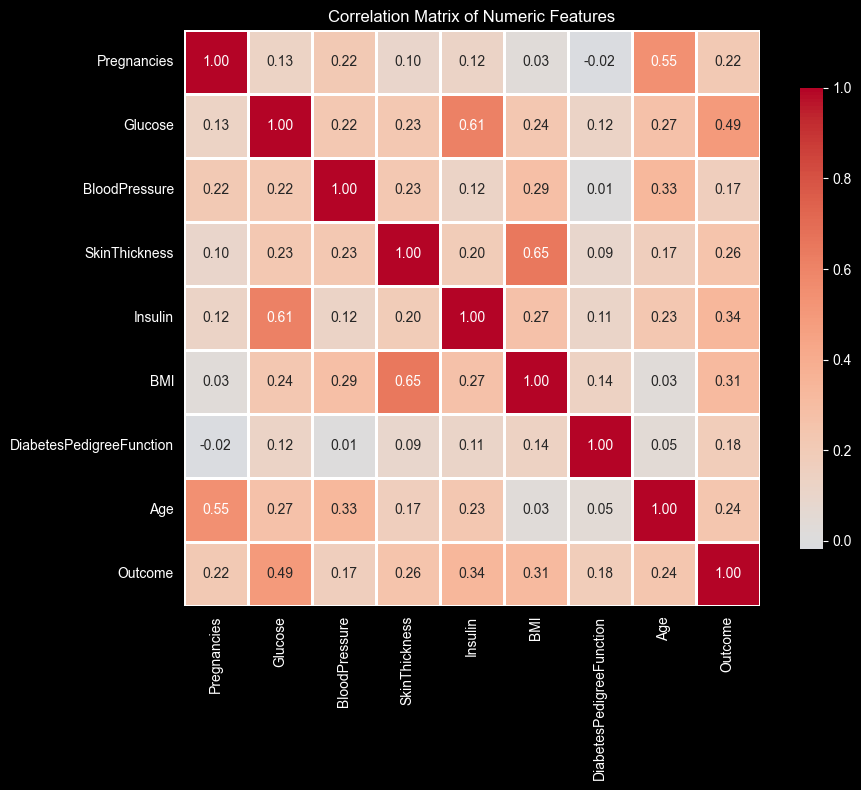

Correlation Matrix:
                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.127043       0.215491       0.098980   
Glucose                      0.127043  1.000000       0.223192       0.228043   
BloodPressure                0.215491  0.223192       1.000000       0.226839   
SkinThickness                0.098980  0.228043       0.226839       1.000000   
Insulin                      0.120069  0.613878       0.118963       0.196383   
BMI                          0.027843  0.235458       0.285153       0.653522   
DiabetesPedigreeFunction    -0.017522  0.118395       0.009200       0.092916   
Age                          0.545528  0.267136       0.330107       0.166816   
Outcome                      0.220946  0.494650       0.170589       0.259491   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.120069  0.027843                 -0.017522   
Glucose              

In [274]:

# Compute correlation matrix for numeric features
correlation_matrix = df_processed[numeric_features + ['Outcome']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_matrix)

## Step 6: Split Data

In [275]:
X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 7: Create Preprocessing Pipeline

In [276]:
# Numerical pipeline: Impute → Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute → Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combined pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 3. Pipeline Creation

In [277]:
# Pipeline 1: Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_model)
])


In [278]:
# Pipeline 2: Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced_subsample'
)

random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', random_forest_model)
])


In [279]:
# Pipeline 3: Stacking Classifier

# Calculate scale_pos_weight for class imbalance
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgboost_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=ratio,  # ← Handles class imbalance
)

stacking_model = StackingClassifier(
    estimators=[
        ('logistic', logistic_model),
        ('random_forest', random_forest_model),
        ('xgboost', xgboost_model)
    ],
    final_estimator=logistic_model,

    n_jobs=-1)

stacking_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_model)
])

In [280]:
# Store all pipelines
model_pipelines = {
    'Logistic Regression': logistic_pipeline,
    'Random Forest': random_forest_pipeline,
    'Stacking Ensemble': stacking_pipeline
}


# 4. Primary Model Selection

I've chosen Random Forest as my primary model because it strikes the perfect balance for our diabetes prediction task.
Unlike simple models like Logistic Regression that might miss complex medical patterns, Random Forest can capture the
intricate relationships between health indicators like glucose levels, BMI, and age. It's robust enough to handle
our dataset's outliers in insulin measurements while providing clear feature importance - crucial for doctors to
understand which factors drive diabetes risk. Plus, its built-in handling of class imbalance ensures we don't overlook
diabetic cases just because they're less common in our data.

In [281]:
primary_model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced_subsample'
)

# Create pipeline with Random Forest as primary model
primary_pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', primary_model_rf)
])

# 5. Model Training

In [282]:
result = []

for name, model in model_pipelines.items():
    # Train model
    model.fit(X_train, y_train)


    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]


    # Calculate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    result.append({
        'Model': name,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
    })

results_df = pd.DataFrame(result).sort_values("ROC-AUC", ascending=False)
print("\nModel Training Results:")
print(results_df)


Model Training Results:
                 Model  Accuracy   ROC-AUC  Precision    Recall  F1-Score
1        Random Forest  0.740260  0.838981   0.652174  0.555556   0.60000
2    Stacking Ensemble  0.746753  0.830741   0.605634  0.796296   0.68800
0  Logistic Regression  0.740260  0.823519   0.597222  0.796296   0.68254


# 6. Cross-Validation

In [283]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Stacking Ensemble": stacking_pipeline
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )
    cv_results[name] = {
        "Mean F1": scores.mean(),
        "Std F1": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T
print(cv_results_df)


                      Mean F1    Std F1
Logistic Regression  0.680321  0.031475
Random Forest        0.629276  0.032685
Stacking Ensemble    0.673663  0.034044


# Task 7: Hyperparameter Tuning

In [284]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [10, 20],
    'classifier__min_samples_leaf': [4, 8],
    'classifier__max_features': ['sqrt', 0.5],
    'classifier__max_samples': [0.8, 0.9]
}
grid_search = GridSearchCV(
    estimator=primary_pipeline_rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [285]:
grid_search.fit(X_train, y_train)

for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

# Compare with baseline (untuned model)
baseline_score = cross_val_score(
    primary_pipeline_rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df.sort_values('mean_test_score', ascending=False).head()
for i, (_, row) in enumerate(top_results.iterrows(), 1):
    print(f"\n{i}. Score: {row['mean_test_score']:.3f}")
    print(f"   Params: {row['params']}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
classifier__max_depth: 15
classifier__max_features: sqrt
classifier__max_samples: 0.9
classifier__min_samples_leaf: 4
classifier__min_samples_split: 20
classifier__n_estimators: 200

1. Score: 0.841
   Params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__max_samples': 0.9, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 200}

2. Score: 0.841
   Params: {'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__max_samples': 0.9, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 200}

3. Score: 0.841
   Params: {'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__max_samples': 0.8, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 100}

4. Score: 0.841
   Params: {'classifier__max_depth': 20, 'clas

In [286]:
from sklearn.model_selection import RandomizedSearchCV

# Define expanded parameter distribution for RandomizedSearch
random_param_dist = {
    'classifier__n_estimators': [100, 150, 200, 250, 300],
    'classifier__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'classifier__min_samples_split': [2, 5, 10, 15, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8, 10],
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'classifier__max_samples': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__bootstrap': [True, False],
    'classifier__criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    estimator=primary_pipeline_rf,
    param_distributions=random_param_dist,
    n_iter=50,  # Test 50 random combinations
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Performing Randomized Search (50 iterations)...")
random_search.fit(X_train, y_train)

print("\nRandomized Search Best Parameters:")
for param, value in random_search.best_params_.items():
    param_name = param.replace('classifier__', '')
    print(f"  {param_name}: {value}")

print(f"\nRandomized Search Best CV Score: {random_search.best_score_:.3f}")

# Compare GridSearch vs RandomizedSearch
print("\n" + "=" * 60)
print("COMPARISON: GRID SEARCH vs RANDOMIZED SEARCH")
print("=" * 60)
print(f"Grid Search: {grid_search.best_score_:.3f} ROC-AUC")
print(f"Randomized Search: {random_search.best_score_:.3f} ROC-AUC")
print(f"Number of combinations tested:")
print(f"  - Grid Search: {len(grid_search.cv_results_['params'])}")
print(f"  - Randomized Search: {random_search.n_iter}")

# Select best search method
if random_search.best_score_ > grid_search.best_score_:
    print("\nRandomized Search found better parameters")
    best_search = random_search
else:
    print("\n Grid Search found better parameters")
    best_search = grid_search

Performing Randomized Search (50 iterations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/nuray-alam/all-works/projects/diabetes_prediction_system/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
145 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
145 fits failed with the following error:
Traceback (most recent call last):
  File "/home/nuray-alam/all-works/projects/diabetes_prediction_system/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/nuray-alam/all-works/projects/diabetes_prediction_system/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
 


Randomized Search Best Parameters:
  n_estimators: 250
  min_samples_split: 20
  min_samples_leaf: 1
  max_samples: 0.7
  max_features: 0.3
  max_depth: 20
  criterion: entropy
  bootstrap: True

Randomized Search Best CV Score: 0.842

COMPARISON: GRID SEARCH vs RANDOMIZED SEARCH
Grid Search: 0.841 ROC-AUC
Randomized Search: 0.842 ROC-AUC
Number of combinations tested:
  - Grid Search: 96
  - Randomized Search: 50

Randomized Search found better parameters


# 8. Best Model Selection

In [287]:
# Get the best model from the best search method
best_model = best_search.best_estimator_
best_params = best_search.best_params_
best_score = best_search.best_score_

# Test score
test_score = best_model.score(X_test, y_test)

print(f"\nSelected Search Method: {'Randomized Search' if best_search == random_search else 'Grid Search'}")
print(f"Best CV Score (ROC-AUC): {best_score:.3f}")
print(f"Test Set Accuracy: {test_score:.3f}")

print(f"\nBest Hyperparameters:")
print("-" * 40)
for param, value in best_params.items():
    param_name = param.replace('classifier__', '')
    print(f"{param_name:20}: {value}")

# Create final model with best parameters
final_model = best_model



Selected Search Method: Randomized Search
Best CV Score (ROC-AUC): 0.842
Test Set Accuracy: 0.727

Best Hyperparameters:
----------------------------------------
n_estimators        : 250
min_samples_split   : 20
min_samples_leaf    : 1
max_samples         : 0.7
max_features        : 0.3
max_depth           : 20
criterion           : entropy
bootstrap           : True


# 9. Model Performance Evaluation

In [288]:
# Make predictions with final model
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)

print(f"\nOverall Metrics:")
print("-" * 40)
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")



PERFORMANCE METRICS

Overall Metrics:
----------------------------------------
Accuracy:  0.727
Precision: 0.594
Recall:    0.704
F1-Score:  0.644
ROC-AUC:   0.828


In [289]:
print("\nDetailed Classification Report:")
print("-" * 40)
print(classification_report(y_test, y_pred,
                            target_names=['Non-Diabetic', 'Diabetic']))


Detailed Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.74      0.78       100
    Diabetic       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



In [290]:
# Confusion Matrix
print("\nConfusion Matrix:")
print("-" * 40)
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (TN): {cm[0, 0]:3d}  |  False Positives (FP): {cm[0, 1]:3d}")
print(f"False Negatives (FN): {cm[1, 0]:3d}  |  True Positives (TP): {cm[1, 1]:3d}")
print(f"\nTotal Samples: {len(y_test)}")
print(f"Correct Predictions: {cm[0, 0] + cm[1, 1]} ({accuracy * 100:.1f}%)")


Confusion Matrix:
----------------------------------------
True Negatives (TN):  74  |  False Positives (FP):  26
False Negatives (FN):  16  |  True Positives (TP):  38

Total Samples: 154
Correct Predictions: 112 (72.7%)


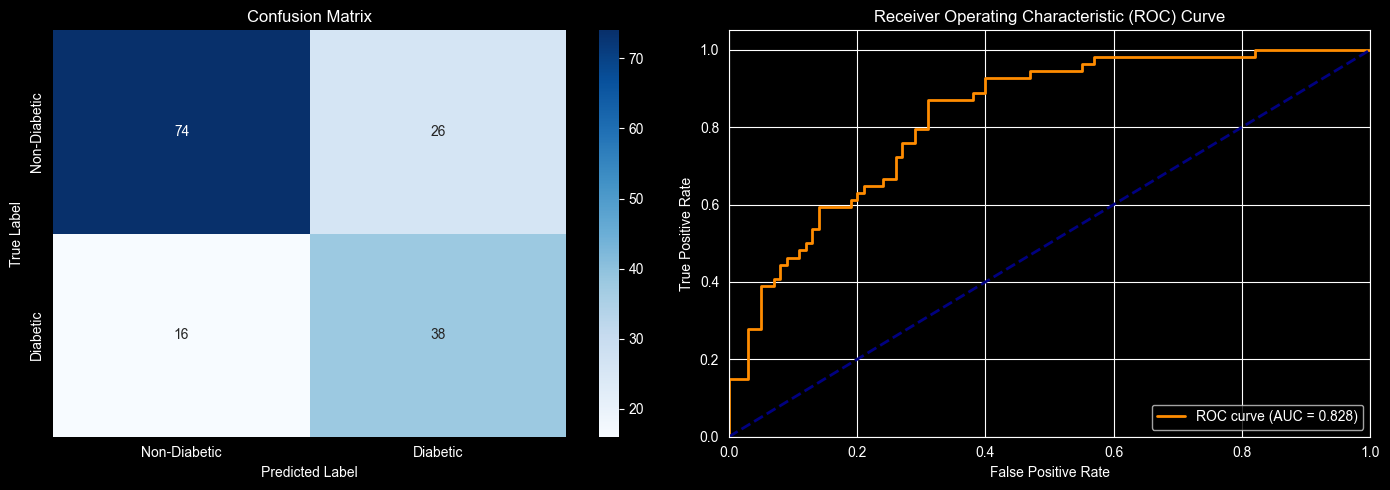

In [291]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()



# 10. Save The Model Using Pickle

In [292]:
import pickle
# Save the final model to a file
model_filename = 'diabetes_prediction_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(final_model, file)
print(f"Model saved to {model_filename}")


Model saved to diabetes_prediction_model.pkl
